# Upload & clean Spotify streaming history over 2023-24.

In [ ]:
# @title Upload streaming history data through Google Drive
import pandas as pd

from google.colab import drive

drive.mount('/content/drive')

# grab csv files containing streaming history from 2022-2024 from my drive
data1 = pd.read_csv('/content/drive/My Drive/seng474/Streaming_History_Audio_2022-2023_3.csv')
data2 = pd.read_csv('/content/drive/My Drive/seng474/Streaming_History_Audio_2023-2024_4.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Here we combine the csv files into one data frame. We then drop any data that is irrelevent to us. Since we are looking at song data over the span of 2023 and 2024 we use regex to keep songs listened to in those two years and to store the day, month, and year as separate attributes.

In [ ]:
# combine the two files into one dataframe
comb = pd.concat([data1, data2], axis=0)

# drop any unnecessary columns
df = comb.drop(['username', 'platform', 'ms_played', 'ip_addr_decrypted',	'user_agent_decrypted',	'master_metadata_album_album_name', 'episode_name',	'episode_show_name',	'spotify_episode_uri',	'reason_start',	'reason_end',	'shuffle',	'skipped',	'offline',	'offline_timestamp',	'incognito_mode'], axis=1)

print("length of df", len(df))

# grab only streaming history from 2023 or 2024
pattern_year = '^202[3,4]'  # Regular expression pattern to match timestamps that begin with 2023
df = df[df['ts'].str.contains(pattern_year)]

# remove any items that are missing information
df.dropna(inplace=True)

# regex to extract year, month, and day and apply to ts
pattern = r'(\d{4})-(\d{2})-(\d{2})T'
df[['Year', 'Month', 'Day']] = df['ts'].str.extract(pattern)

# set the date information as ints
df["Year"] = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)
df["Day"] = df["Day"].astype(int)

# create a attribute that tells you the day of the year a song was listened to
df["day_of_year"] = df["Year"].map(str) + "-" + df["Month"].map(str).str.zfill(2) + "-" + df["Day"].map(str).str.zfill(2)

# drop the timestamp since we now have all relevent data
df = df.drop('ts', axis=1)

df.head()

length of df 29203


,conn_country,master_metadata_track_name,master_metadata_album_artist_name,spotify_track_uri,Year,Month,Day,day_of_year
5213,CA,Bruises & Scratches,Sophie May,spotify:track:1E3vswBWNDxpJcopj8E7iB,2023,1,1,2023-01-01
5214,CA,INVU,TAEYEON,spotify:track:7rXcCpIAoOUCydkVDMcoPV,2023,1,1,2023-01-01
5215,CA,Make Me Happy,Whee In,spotify:track:6ry670EtSALRt1yd0W0wca,2023,1,1,2023-01-01
5216,CA,Cupid,Alexandra Savior,spotify:track:6yu9LcfTlFwc16D3xtJ8AI,2023,1,1,2023-01-01
5217,CA,505,Arctic Monkeys,spotify:track:58ge6dfP91o9oXMzq3XkIS,2023,1,1,2023-01-01


In [ ]:
# @title Grab date range from March 26, 2023 to February 26, 2024

df_can = df[(df["conn_country"] == "CA")]

streaming_df = df_can[((df_can["Year"] == 2023) & (df_can["Month"] >= 4)) |
        ((df_can["Year"] == 2023) & (df_can["Month"] == 3) & (df_can["Day"] >= 26)) |
        ((df_can["Year"] == 2024) & ((df_can["Month"] == 1) | ((df_can["Month"] == 2) & (df_can["Day"] <= 26))))]

print("number of songs listened to from March 26, 2023 to February 26, 2024:" ,len(streaming_df))

number of songs listened to from March 26, 2023 to February 26, 2024: 18002


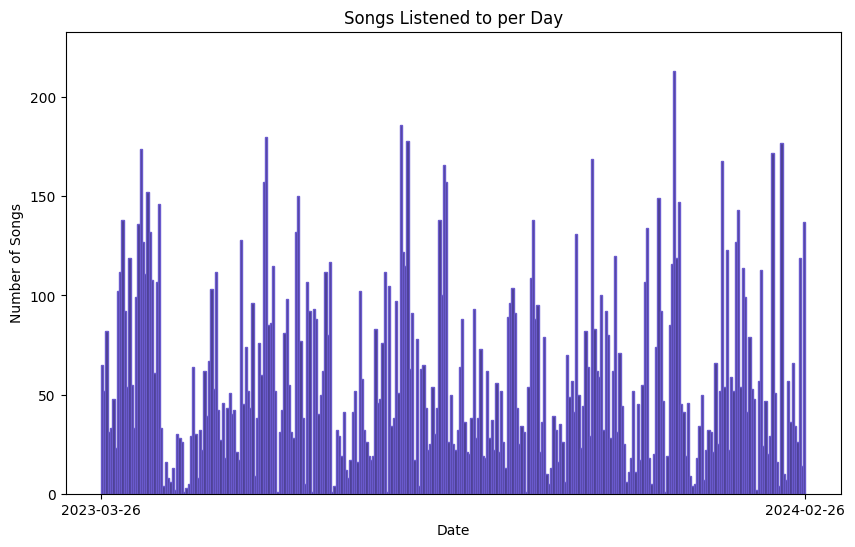

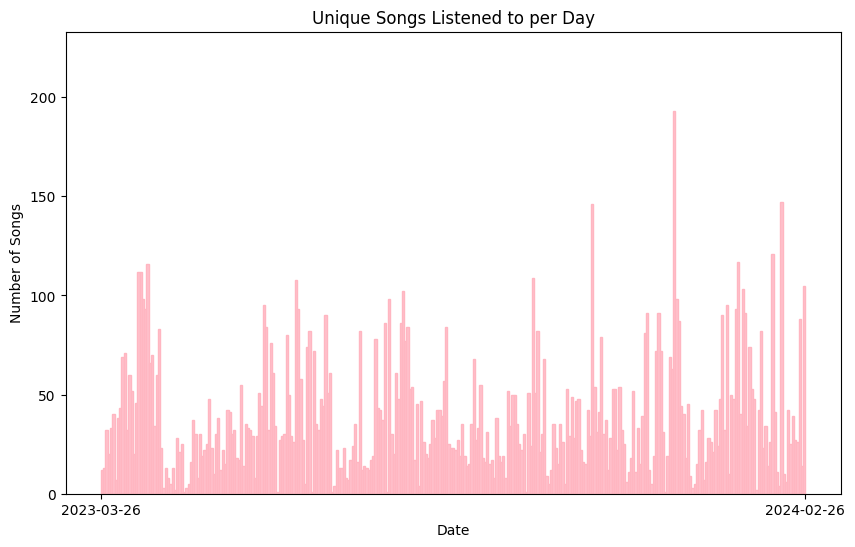

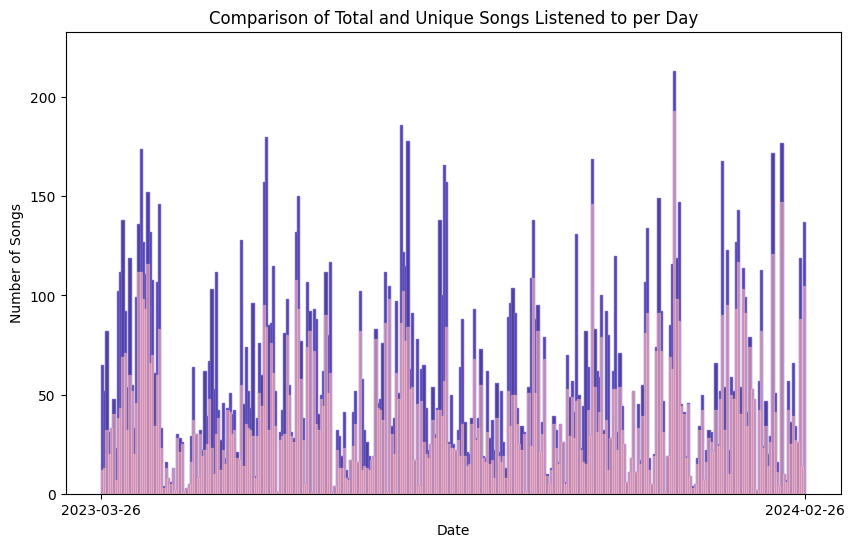

In [ ]:
# @title Songs per day plots
import matplotlib.pyplot as plt

# count occurrences of each date and sort by index
counts = streaming_df['day_of_year'].value_counts().sort_index()

# group by 'day_of_year' and count unique songs
unique_songs_per_day = streaming_df.groupby('day_of_year')['spotify_track_uri'].nunique()

# plot songs per day (histogram)
plt.figure(figsize=(10, 6))
plt.hist(counts.index, bins=len(counts), weights=counts.values, color='darkslateblue', edgecolor='slateblue')
plt.xlabel('Date')
plt.xticks([counts.index[0], counts.index[-1]], ha='center')
plt.ylabel('Number of Songs')
plt.ylim(0, max(counts)+20) # ensure the range for the count remains the same for all plots
plt.title('Songs Listened to per Day')
plt.show()

# plot unique song per day (histogram)
plt.figure(figsize=(10, 6))
plt.hist(unique_songs_per_day.index, bins=len(unique_songs_per_day), weights=unique_songs_per_day.values, color='pink', edgecolor='lightpink')
plt.xlabel('Date')
plt.xticks([unique_songs_per_day.index[0], unique_songs_per_day.index[-1]], ha='center')
plt.ylabel('Number of Songs')
plt.ylim(0, max(counts)+20) # ensure the range for the count remains the same for all plots
plt.title('Unique Songs Listened to per Day')
plt.show()

# plot histograms on top of eachother
plt.figure(figsize=(10, 6))
plt.hist(counts.index, bins=len(counts), weights=counts.values, color='darkslateblue', edgecolor='slateblue', label='Total Songs Listened')
plt.hist(unique_songs_per_day.index, bins=len(unique_songs_per_day), weights=unique_songs_per_day.values, color='pink', edgecolor='lightpink', alpha=0.5, label='Total Unique Songs')
plt.xlabel('Date')
plt.xticks([counts.index[0], counts.index[-1]], ha='center')
plt.ylabel('Number of Songs')
plt.ylim(0, max(counts)+20) # ensure the range for the count remains the same for all plots
plt.title('Comparison of Total and Unique Songs Listened to per Day')
plt.show()

These plots show the amount of music listened to over the span of a year. We can see that often times the days I listen to the most music I am listening to the same songs repeatedly.

# Use spotipy to interact with the Spotify API

We now grab all of the data related to the songs we've listened to over the past year

In [ ]:
# @title downloaded spotify api
!pip install spotipy

In [ ]:
# @title connect and authorize spotify connection
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Client ID and Secret
cid="insert your client ID"
cs="insert your client secret"

In [ ]:
#Authentication - without user
# code taken from: https://towardsdatascience.com/extracting-song-data-from-the-spotify-api-using-python-b1e79388d50
client_credentials_manager = SpotifyClientCredentials(client_id=cid, client_secret=cs)
sp = spotipy.Spotify(client_credentials_manager = client_credentials_manager)

<h3>Now we grab the information on tracks that we listened to throughout the year.</h3>

In [ ]:
# grab the uri's for each track and remove the prefixes, grab only the unique track id's
track_uri = streaming_df["spotify_track_uri"]
unique_uris = set(track_uri)
track_ids = list(unique_uris)

# number of songs vs. number of unique songs
print(len(track_uri), "songs were listened to over the time frame,", len(track_ids), "of which are unique.")

# the audio features call can only do batch calls of size 100, so
# we iterate through all of the unique songs listened to over the year
size = 100
num_batches = len(track_ids) // size

# all song data will be collected here
audio_features = []

for i in range(num_batches):
    start = i * size
    end = (i + 1) * size
    batch = track_ids[start:end]
    audio_features.append(sp.audio_features(tracks=batch))

# remaining elements
remaining_elements = track_ids[num_batches * size:]
audio_features.append(sp.audio_features(tracks=remaining_elements))


18002 songs were listened to over the time frame, 3857 of which are unique.


In [ ]:
import json
print("preview of song data:",json.dumps(audio_features[0][0], indent=1))

preview of song data: {
 "danceability": 0.68,
 "energy": 0.701,
 "key": 5,
 "loudness": -5.001,
 "mode": 1,
 "speechiness": 0.0917,
 "acousticness": 0.138,
 "instrumentalness": 0.000191,
 "liveness": 0.168,
 "valence": 0.649,
 "tempo": 94.06,
 "type": "audio_features",
 "id": "6uAFJ75WDAoAPyCWJAtvks",
 "uri": "spotify:track:6uAFJ75WDAoAPyCWJAtvks",
 "track_href": "https://api.spotify.com/v1/tracks/6uAFJ75WDAoAPyCWJAtvks",
 "analysis_url": "https://api.spotify.com/v1/audio-analysis/6uAFJ75WDAoAPyCWJAtvks",
 "duration_ms": 218754,
 "time_signature": 4
}


In [ ]:
# @title create a dataframe that has all of the relevent song data
# reformat the list so it can be turned into a df
# some entries didn't return anything so we remove any of those
audio_features = [item for sublist in audio_features for item in sublist if item is not None]

song_df = pd.DataFrame(audio_features)
print("shape of song_df:", song_df.shape)

# display the df
song_df.head()

shape of song_df: (3855, 18)


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,0.680,0.701,5,-5.001,1,0.0917,0.138000,0.000191,0.1680,0.6490,94.060,audio_features,6uAFJ75WDAoAPyCWJAtvks,spotify:track:6uAFJ75WDAoAPyCWJAtvks,https://api.spotify.com/v1/tracks/6uAFJ75WDAoA...,https://api.spotify.com/v1/audio-analysis/6uAF...,218754,4
1,0.656,0.421,0,-7.404,1,0.0238,0.087300,0.000000,0.1130,0.2370,79.906,audio_features,6Wjtz36Bod5mr2c3jiXl1r,spotify:track:6Wjtz36Bod5mr2c3jiXl1r,https://api.spotify.com/v1/tracks/6Wjtz36Bod5m...,https://api.spotify.com/v1/audio-analysis/6Wjt...,296600,4
2,0.586,0.874,11,-5.535,1,0.0416,0.003830,0.000001,0.2220,0.7560,130.083,audio_features,3Ar4cp3V0SeWXEuRelC86p,spotify:track:3Ar4cp3V0SeWXEuRelC86p,https://api.spotify.com/v1/tracks/3Ar4cp3V0SeW...,https://api.spotify.com/v1/audio-analysis/3Ar4...,234346,4
3,0.225,0.275,3,-11.988,0,0.0424,0.683000,0.000175,0.1590,0.0405,119.257,audio_features,3tMQKPLplBCDdOgdsZn0SZ,spotify:track:3tMQKPLplBCDdOgdsZn0SZ,https://api.spotify.com/v1/tracks/3tMQKPLplBCD...,https://api.spotify.com/v1/audio-analysis/3tMQ...,63587,3
4,0.493,0.772,1,-6.315,1,0.0510,0.000064,0.000018,0.0925,0.4120,133.973,audio_features,6QcOEPC0bX799hITIgj3vU,spotify:track:6QcOEPC0bX799hITIgj3vU,https://api.spotify.com/v1/tracks/6QcOEPC0bX79...,https://api.spotify.com/v1/audio-analysis/6QcO...,215734,3


In [ ]:
# @title export song df to a csv file
# if we want to add any additional data we can just append using --> mode='a'
song_df.to_csv('/content/drive/My Drive/seng474/year_of_song_data.csv', index=False)

# Combining the two dataframes
We have currently have a streaming df and a song information df

In [ ]:
# @title combine streaming_df and song_df by track uri
merged_df = pd.merge(streaming_df, song_df, left_on='spotify_track_uri', right_on='uri')

music = merged_df.drop(['spotify_track_uri', 'type', 'id', 'track_href', 'analysis_url', 'duration_ms', 'time_signature'],axis=1)

Since we have chosen to look at daily trends we will average the song data by day.

In [ ]:
# @title get average stats per day
averages_df = music.groupby(['day_of_year']).mean(numeric_only=True).reset_index()

# display the df with averages
averages_df.head()

,day_of_year,Year,Month,Day,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,2023-03-26,2023.0,3.0,26.0,0.696077,0.727185,7.015385,-4.404508,0.261538,0.085526,0.224166,0.018580,0.213138,0.593508,127.187569
1,2023-03-27,2023.0,3.0,27.0,0.663808,0.682962,6.500000,-5.713577,0.653846,0.095188,0.171101,0.022337,0.128423,0.477288,102.203385
2,2023-03-28,2023.0,3.0,28.0,0.596720,0.690524,6.207317,-6.300171,0.548780,0.081926,0.216419,0.052258,0.172535,0.534695,117.856134
3,2023-03-29,2023.0,3.0,29.0,0.703742,0.641645,5.967742,-6.306129,0.580645,0.080661,0.259697,0.017596,0.145681,0.563355,112.273839
4,2023-03-30,2023.0,3.0,30.0,0.556939,0.642727,5.484848,-7.693333,0.515152,0.064403,0.252214,0.042283,0.173073,0.506636,121.372636


In [ ]:
# @title save averages dataframe
averages_df.to_csv('/content/drive/My Drive/seng474/my_history_valence.csv', index=False)

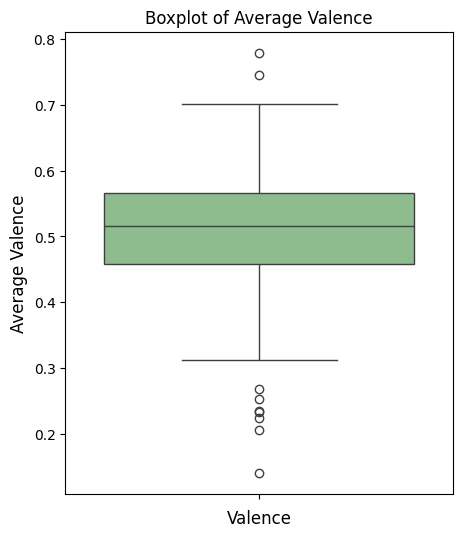

In [ ]:
# @title boxplot of average valence
import seaborn as sns

# create a boxplot
plt.figure(figsize=(5, 6))
sns.boxplot(y=averages_df['valence'], boxprops=dict(facecolor='darkseagreen'))
plt.xlabel('Valence', fontsize=12)
plt.ylabel('Average Valence', fontsize=12)
plt.title('Boxplot of Average Valence')
plt.show()

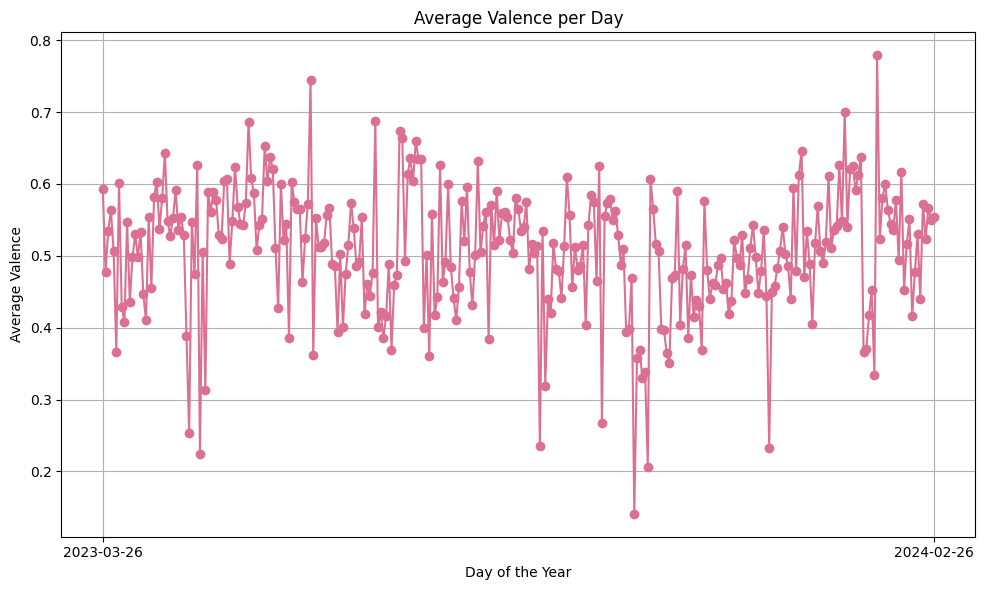

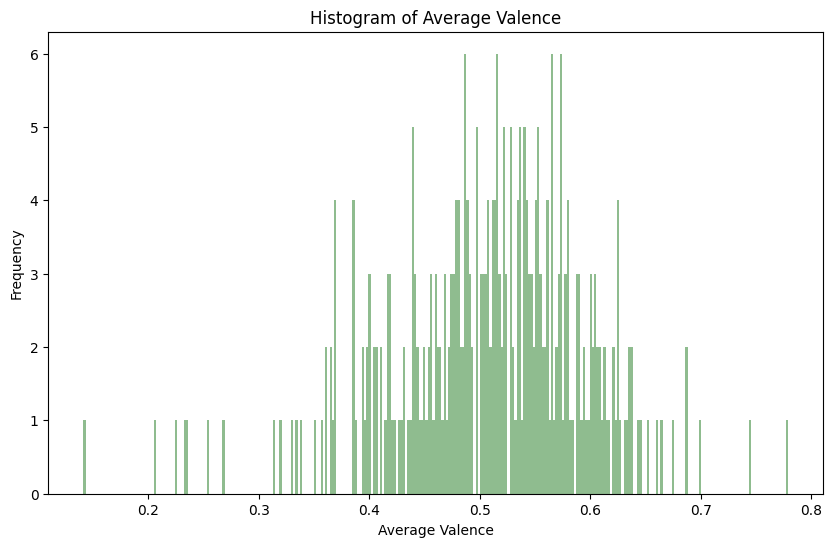

In [ ]:
from operator import index
# @title scatter plot of average valence per day
plt.figure(figsize=(10, 6))
plt.plot(averages_df['day_of_year'], averages_df['valence'], marker='o', linestyle='-', color='palevioletred')

# add visual separators for month
for month in averages_df['Month'].unique():
    idx = averages_df[averages_df['Month'] == month].index[0]
    plt.axvline(x=idx, color='grey', linestyle='--', linewidth=0.01)

plt.xlabel('Day of the Year')
plt.xticks([averages_df['day_of_year'].index[0], averages_df['day_of_year'].index[-1]], ha='center')
plt.ylabel('Average Valence')
plt.title('Average Valence per Day')
plt.grid(True)
plt.tight_layout()
plt.show()

# plot a histogram of avg valence
plt.figure(figsize=(10, 6))
plt.hist(averages_df['valence'], bins=len(averages_df['valence']), color='darkseagreen')
plt.xlabel('Average Valence')
plt.ylabel('Frequency')
plt.title('Histogram of Average Valence')
plt.show()